In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

In [2]:
orders = pd.read_csv('../data/olist_orders_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
translation = pd.read_csv('../data/product_category_name_translation.csv')

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Cleanup

In [3]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for columns in date_columns:
    orders[columns] = pd.to_datetime(orders[columns])

clean_orders = orders[orders["order_status"] == "delivered"].copy()

print(f"Total orders: ${len(orders)}")
print(f"Delivered orders: ${len(clean_orders)}")
print(f"Other order status: ${len(orders[orders.order_status != "delivered"])}")
print(f"All orders status : {orders['order_status'].value_counts().to_dict()}")

Total orders: $99441
Delivered orders: $96478
Other order status: $2963
All orders status : {'delivered': 96478, 'shipped': 1107, 'canceled': 625, 'unavailable': 609, 'invoiced': 314, 'processing': 301, 'created': 5, 'approved': 2}


In [4]:
df = (clean_orders
      .merge(customers, on='customer_id')
      .merge(items, on='order_id')
      .merge(payments, on='order_id')
      .merge(products, on='product_id')
      .merge(translation, on='product_category_name', how='left')
      .merge(sellers, on='seller_id')
)
df.shape

(115035, 34)

In [12]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['year'] = df['order_purchase_timestamp'].dt.year
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()
df['hour'] = df['order_purchase_timestamp'].dt.hour

df['revenue'] = df['price'] + df['freight_value'] # total revenue per article
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days # delivery retardation
df[['price', 'freight_value', 'revenue', 'delay_days']].head()

0          38.71
1          38.71
2          38.71
3         141.46
4         179.12
           ...  
115030    195.00
115031    271.01
115032    220.58
115033    220.58
115034     86.86
Name: revenue, Length: 115035, dtype: float64

### Global KPIs - Key Performance Indicator

In [6]:
total_price = df['price'].sum()
distinct_total_order = df['order_id'].nunique()
mean_hod = df.groupby('order_id')['price'].sum().mean()
total_customer = df['customer_unique_id'].nunique()
mean_score = reviews['review_score'].mean()

print(f"Total price: R$ {total_price:,.0f}")
print(f"Total orders: {distinct_total_order:,}")
print(f"Mean hod: R$ {mean_hod:.2f}")
print(f"Unique customers: {total_customer:,}")
print(f"Mean score: {mean_score:.2f} / 5")

Total price: R$ 13,813,829
Total orders: 96,477
Mean hod: R$ 143.18
Unique customers: 93,357
Mean score: 4.09 / 5


### Monthly revenue

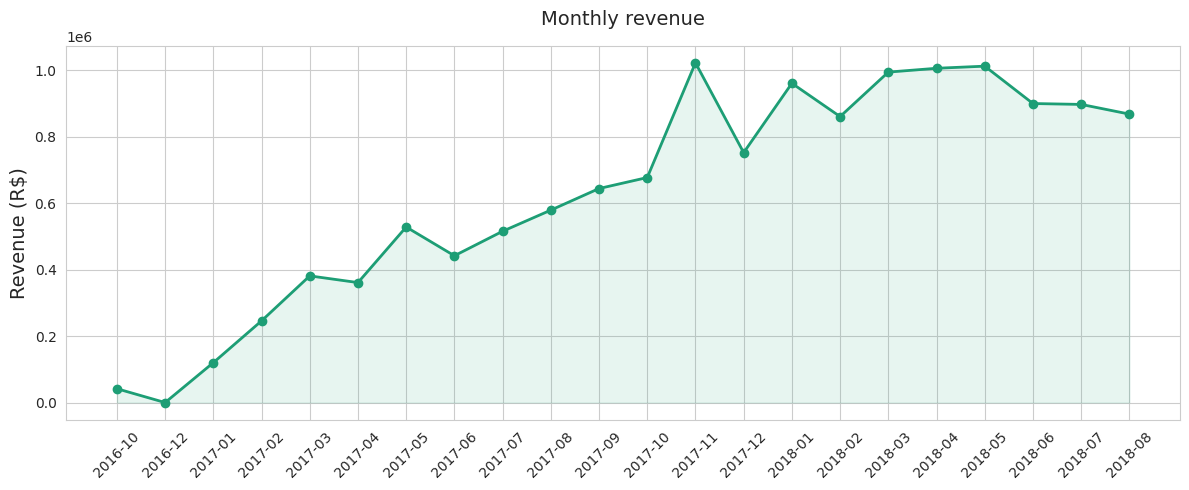

In [53]:
monthly_total_price = (df.groupby('month')['price'].sum().reset_index())
monthly_total_price['month_in_str'] = monthly_total_price['month'].astype(str)

fig, ax = plt.subplots()
ax.plot(monthly_total_price['month_in_str'], monthly_total_price['price'], marker='o', linewidth=2, color='#1D9E75')

ax.fill_between(monthly_total_price['month_in_str'], monthly_total_price['price'], alpha=0.1, color='#1D9E75')
ax.set_title('Monthly revenue', fontsize=14, pad=15)
ax.set_ylabel('Revenue (R$)', fontsize=14)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../outputs/monthly_revenue.png', dpi=150)


### Top 10 categories most sold

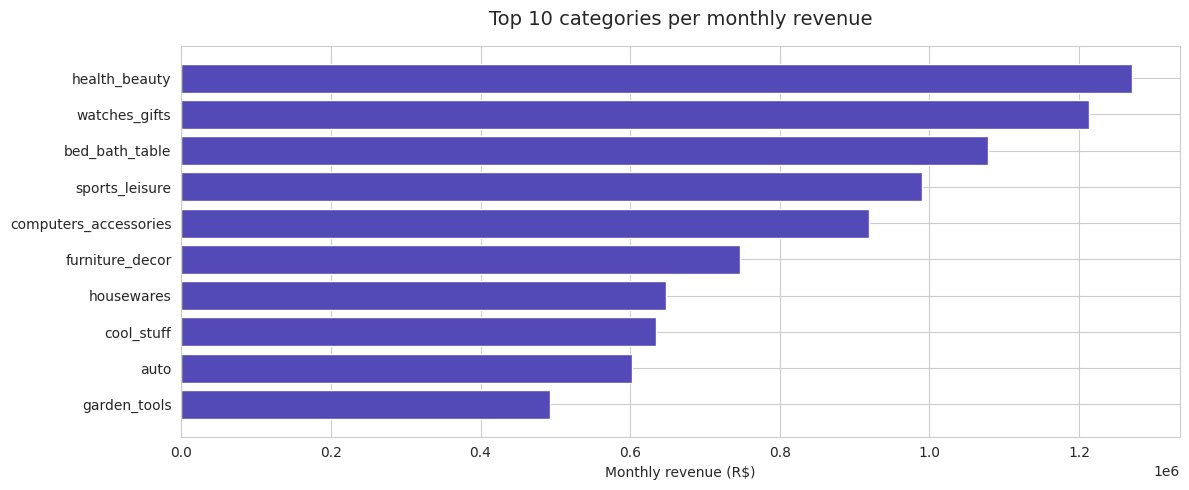

In [71]:
top_categories = df.groupby('product_category_name_english')['price'].sum().nlargest(10).reset_index()

fig, ax = plt.subplots()
ax.barh(top_categories['product_category_name_english'], top_categories['price'], color='#534AB7')
ax.set_title('Top 10 categories per monthly revenue', fontsize=14, pad=15)
ax.set_xlabel('Monthly revenue (R$)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/top_categories.png', dpi=150)
plt.show()